## **Importing the necessary Libraries.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, f1_score, confusion_matrix, classification_report, precision_score, recall_score
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

## **DATA PREPARATION.**

**1.1.** Reading in the data.

In [ ]:
us_ml = pd.read_csv("./us_df_clean (1).csv")
us_ml.head()

,year,weight,total_income,wage_income,total_earnings,state,region,gender,immigrant_status,education
0,2018,107,0.0,0.0,0,California,California,Female,Immigrant,Less than high school
1,2018,240,20000.0,20000.0,20000,Florida,Rest of US,Male,Born in US,Less than high school
2,2018,94,0.0,0.0,0,California,California,Male,Born in US,University degree
3,2018,175,103700.0,0.0,0,Arizona,Rest of US,Male,Born in US,High school diploma
4,2018,49,40000.0,40000.0,40000,Georgia,Rest of US,Female,Born in US,University degree


**1.2.** Creating a copy of the data.

In [ ]:
us_copy = us_ml.copy()

In [ ]:
us_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430962 entries, 0 to 430961
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              430962 non-null  int64  
 1   weight            430962 non-null  int64  
 2   total_income      430962 non-null  float64
 3   wage_income       424253 non-null  float64
 4   total_earnings    430962 non-null  int64  
 5   state             430962 non-null  object 
 6   region            430962 non-null  object 
 7   gender            430962 non-null  object 
 8   immigrant_status  430962 non-null  object 
 9   education         430962 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 32.9+ MB


In [ ]:
us_copy.isna().sum()

,0
year,0
weight,0
total_income,0
wage_income,6709
total_earnings,0
state,0
region,0
gender,0
immigrant_status,0
education,0


In [ ]:
us_copy['region'].value_counts()

,count
region,
Rest of US,279736
California,151226


**1.3.** Creating a new column called "Income Level" from the "total income" column.

**1.3.1.** Removing invalid income values.

In [ ]:
us_copy['total_income'] = us_copy['total_income'].replace([9999999,9999998],np.nan)
us_copy= us_copy[us_copy['total_income'].notna()]

us_copy= us_copy[us_copy['total_income'] > 0]

us_copy.reset_index(drop= True, inplace= True)

**1.3.2.** Splitting the training and testing dataset by Region.

In [ ]:
train_us = us_copy[us_copy['region'] == 'California'].copy()
test_us = us_copy[us_copy['region'] == "Rest of US"].copy()

In [ ]:
print(train_us.shape)
print(test_us.shape)

(126993, 10)
(242880, 10)


**1.3.3.** Creating the California-based income cutoffs.

**1.3.3.1.** Creating the threshold levels.

In [ ]:
q1, q2 = train_us['total_income'].quantile([0.33, 0.66])

**1.3.3.2.** Using the California cutoffs to label both the training and testing dataset.

This is because we are using California as a reference scale to evaluate whether California-based income structures generalizes with to the Rest of US.

In [ ]:
def income_level(x):
  if x <=q1:
    return "Low"
  elif x<= q2:
    return "Medium"
  else:
    return "High"

In [ ]:
train_us['income_level'] = train_us['total_income'].apply(income_level)
test_us['income_level'] = test_us['total_income'].apply(income_level)

In [ ]:
print(train_us['income_level'].value_counts(dropna= False))
print()
print(test_us['income_level'].value_counts(dropna= False))

income_level
High      42800
Low       42241
Medium    41952
Name: count, dtype: int64

income_level
Medium    90469
Low       85555
High      66856
Name: count, dtype: int64


In [ ]:
print(train_us.info())
print()
print(test_us.info())

<class 'pandas.core.frame.DataFrame'>
Index: 126993 entries, 7 to 369871
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              126993 non-null  int64  
 1   weight            126993 non-null  int64  
 2   total_income      126993 non-null  float64
 3   wage_income       126817 non-null  float64
 4   total_earnings    126993 non-null  int64  
 5   state             126993 non-null  object 
 6   region            126993 non-null  object 
 7   gender            126993 non-null  object 
 8   immigrant_status  126993 non-null  object 
 9   education         126993 non-null  object 
 10  income_level      126993 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 11.6+ MB
None

<class 'pandas.core.frame.DataFrame'>
Index: 242880 entries, 0 to 369872
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  

# **2.0.** Machine Learning Preprocessing.

**2.1.** Defining the features and Targets variable.

In [ ]:
X_train = train_us.drop(columns= ['total_income', 'income_level', 'region', 'state'])
y_tr_reg = train_us['total_income']
y_tr_clf = train_us['income_level']

In [ ]:
X_test = test_us.drop(columns= ['total_income', 'income_level', 'region', 'state'])
y_te_reg = test_us['total_income']
y_te_clf = test_us['income_level']

In [ ]:
numerical_features = ['total_earnings', 'year', 'weight', 'wage_income']
categorical_features = ['gender', 'immigrant_status', 'education']

In [ ]:
print(X_train.isna().sum())
print()
print(X_test.isna().sum())

year                  0
weight                0
wage_income         176
total_earnings        0
gender                0
immigrant_status      0
education             0
dtype: int64

year                  0
weight                0
wage_income         541
total_earnings        0
gender                0
immigrant_status      0
education             0
dtype: int64


**2.2.** Splitting the training data into training and validation data.

**2.2.1.** For Regression.

In [ ]:
X_train_reg, X_val_reg, y_train_reg, y_val_reg = train_test_split(X_train, y_tr_reg, test_size= 0.2, random_state= 42)

**2.2.2.** For Classification.

In [ ]:
X_train_clf, X_val_clf, y_train_clf, y_val_clf = train_test_split(X_train, y_tr_clf, test_size=0.2, random_state=42, stratify= y_tr_clf)

**2.3.** Building the preprocessor for encoding our categorical values and scaling our Numerical values.

- The pipeline is used to encode, scale and train the model at once in an object instead of writing it in seperate blocks.
- It also learns preprocessing automatically only from the training data, while applying it to the validation/test data.

We are using SimpleImputer because the wage_income column contains missing values, and machine learning models cannot handle missing data directly. Dropping those rows could lead to loss of valuable information, so instead we replace the missing values with the median, which provides a reasonable estimate.

The median is used instead of the mean because income data is typically skewed. The mean can be heavily influenced by extreme high values (outliers), while the median is more robust and provides a more stable central value.

In [ ]:
numeric_transformer =Pipeline(steps = [
    ('imputer', SimpleImputer(strategy= 'median')),
    ('scaler', MinMaxScaler())
])

This code is just to help us confirm that the SimpleImputer is doing what it is supposed to do.

In [ ]:
# X_train_imputed = numeric_transformer.fit_transform(X_train[numerical_features])
# print(pd.DataFrame(X_train_imputed, columns=numerical_features).isna().sum())

For the Categorical values we Encode.
- We are using **One-Hot Encoding** because our categorical values does not have any order attached to them.

- **'handle_unknown = "Ignore"**, prevents the model from crashing if it encounters a new category that the test data did not see during training.

In [ ]:
categorical_transformer = Pipeline(steps= [
    ('onehot', OneHotEncoder(drop="first", handle_unknown="ignore"))
])

- The ColumnTransformer allows us to apply different preprocessing steps to different columns (for example, scaling numeric features and encoding categorical features).

- **Remainder = "drop'**, this ensures that the model only uses the columns we explicitly selected as features. This helps us to prevent accidential data leakage and helps to keep the model clean and controlled.

In [ ]:
preprocessor = ColumnTransformer(transformers= [
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
], remainder= 'drop')

## **3.0.** Model Building.

## **3.1.** Full Model.

#### Based on the requirement for this aspect of the project, we would be making use of all the models we've been thought in class for both Regression and Classification.


##### As this would also help to validate the reason why we are picking our model.

**Column transfer** - Helps to apply different preprocessing to different sets of columns at the same time.

**Pipeline:** - Cleans the data using the Preprocessor, Then proceeds to train the model.

We create a loop to train all the models we've covered in class and then use the validation score to pick the best model then we test only on the best model.

# **3.1.1.** Regression Models.

### **3.1.1.1.** Training and Validating the Regression Models and Creating a dataframe to store the results.

For the regression model we evaluate performance using R², Mean Absolute Error(MAE), and Root Mean Squared Error (RMSE).

- **R²**: Tells us how well the model explains income differences.

- **MAE**: Tells us how wrong the model is on average.

- **RMSE**: Tells us if the model sometimes makes very big mistakes.

In [ ]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=150, learning_rate= 0.1, max_depth=3)
}

reg_val_rows = []
reg_pipes = {}

for name, model in regression_models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Training the models
    pipe.fit(X_train_reg, y_train_reg)

    # Training prediction
    train_pred = pipe.predict(X_train_reg)

    # Validation prediction
    val_pred = pipe.predict(X_val_reg)

    # Scores
    train_r2 = r2_score(y_train_reg, train_pred)
    val_r2 = r2_score(y_val_reg, val_pred)

    train_mae = mean_absolute_error(y_train_reg, train_pred)
    val_mae = mean_absolute_error(y_val_reg, val_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train_reg, train_pred))
    val_rmse = np.sqrt(mean_squared_error(y_val_reg, val_pred))

    reg_val_rows.append([name, train_r2, val_r2, train_mae, val_mae, train_rmse, val_rmse])
    reg_pipes[name] = pipe

reg_val_table = pd.DataFrame(
    reg_val_rows,
    columns=["Model", "Train R2", "Val R2", "Train MAE", "Val MAE", "Train RMSE", "Val RMSE"]
)
reg_val_table = reg_val_table.round(4).sort_values(by="Val R2", ascending=False)
reg_val_table

,Model,Train R2,Val R2,Train MAE,Val MAE,Train RMSE,Val RMSE
4,Gradient Boosting,0.8582,0.8484,11594.4312,11947.2111,31207.4934,32670.6048
1,Decision Tree,0.8696,0.8335,11040.8319,12055.7038,29919.6574,34239.7283
2,Random Forest,0.9112,0.8315,9365.2647,12409.4127,24698.7016,34442.5194
0,Linear Regression,0.8242,0.8183,15718.3258,15916.8427,34745.0390,35772.3893
3,KNN,0.8538,0.8138,12380.1404,14006.4535,31686.8390,36209.7542


### **3.1.1.2.** Testing the Best Regression Model (Selected from Validation).

In [ ]:
best_regression_model = reg_val_table.iloc[0]['Model']
best_regression_pipes = reg_pipes[best_regression_model]
test_prediction = best_regression_pipes.predict(X_test)

test_r2 = r2_score(y_te_reg, test_prediction)
test_mae = mean_absolute_error(y_te_reg, test_prediction)
test_rmse = np.sqrt(mean_squared_error(y_te_reg, test_prediction))

regression_test_scores = []
regression_test_scores.append([best_regression_model, test_r2, test_mae, test_rmse])

print("Best Regression Model:", best_regression_model)
print(f"Test R2 Score: {test_r2:.4f}")
print(f"Test MAE Score: {test_mae:.4f}")
print(f"Test RMSE Score: {test_rmse:.4f}")

test_results_df = pd.DataFrame(regression_test_scores, columns= ["Model", "R2", "MAE", "RMSE"])
test_results_df

Best Regression Model: Gradient Boosting
Test R2 Score: 0.8171
Test MAE Score: 11527.0335
Test RMSE Score: 28887.7389


,Model,R2,MAE,RMSE
0,Gradient Boosting,0.817095,11527.033496,28887.738873


Multiple regression models were trained using California as the benchmark state.

Model selection was based on validation performance, and the best performing model was chosed for final testing on the Rest of the US.

The best-performing regression model was selected based on validation R² and then tested on the Rest of the U.S.
The best-performing classification model was selected based on validation F1-score and then tested on the Rest of the U.S.




# **3.1.2.** Classification Models.

### **3.1.2.1.** Training and Validating the Classification Models and Creating a dataframe to store the results.

In [ ]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=150, learning_rate= 0.1, max_depth=3)
}

clf_val_rows = []
clf_pipes = {}

for name, model in classification_models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train_clf, y_train_clf)

    # Training predictions
    train_pred = pipe.predict(X_train_clf)
    val_pred = pipe.predict(X_val_clf)

    train_acc = accuracy_score(y_train_clf, train_pred)
    val_acc = accuracy_score(y_val_clf, val_pred)

    train_f1 = f1_score(y_train_clf, train_pred, average="weighted")
    val_f1 = f1_score(y_val_clf, val_pred, average="weighted")

    train_precision = precision_score(y_train_clf, train_pred, average="weighted")
    val_precision = precision_score(y_val_clf, val_pred, average="weighted")

    train_recall = recall_score(y_train_clf, train_pred, average="weighted")
    val_recall = recall_score(y_val_clf, val_pred, average="weighted")

    clf_val_rows.append([name, train_acc, val_acc, train_f1, val_f1, train_precision, val_precision, train_recall, val_recall])
    clf_pipes[name] = pipe

clf_val_table = pd.DataFrame(
    clf_val_rows,
    columns=["Model", "Train Accuracy", "Val Accuracy", "Train F1", "Val F1", "Train Precision", "Val Precision", "Train Recall", "Val Recall"]
)

clf_val_table = clf_val_table.sort_values(by="Val F1", ascending=False)
clf_val_table

,Model,Train Accuracy,Val Accuracy,Train F1,Val F1,Train Precision,Val Precision,Train Recall,Val Recall
4,Gradient Boosting,0.869126,0.868381,0.869089,0.868359,0.882134,0.880984,0.869126,0.868381
1,Decision Tree,0.870396,0.866451,0.870683,0.866761,0.882612,0.878480,0.870396,0.866451
2,Random Forest,0.886913,0.865507,0.887087,0.865747,0.896736,0.875632,0.886913,0.865507
3,KNN,0.849302,0.829600,0.849313,0.829858,0.857893,0.837709,0.849302,0.829600
0,Logistic Regression,0.756944,0.758888,0.756464,0.758813,0.763289,0.765620,0.756944,0.758888


### **3.1.2.2.** Testing the Classification Model and Creating a dataframe to store the results.

In [ ]:
best_clf_model = clf_val_table.iloc[0]['Model']
best_clf_pipes = clf_pipes[best_clf_model]

test_pred = best_clf_pipes.predict(X_test)
test_acc = accuracy_score(y_te_clf, test_pred)
test_f1 = f1_score(y_te_clf, test_pred, average="weighted")
test_precision = precision_score(y_te_clf, test_pred, average="weighted")
test_recall = recall_score(y_te_clf, test_pred, average="weighted")

classification_test_scores = []


classification_test_scores.append([best_clf_model, test_acc, test_f1, test_precision, test_recall])


print("Best Classification Model", best_clf_model)
print(f"Test Accuracy Score: {test_acc:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Test Precision Score: {test_precision:.4f}")
print(f"Test Recall Score: {test_recall:.4f}")
print("Confusion Matrix:", confusion_matrix(y_te_clf, test_pred))
print("Classification Report:", classification_report(y_te_clf, test_pred))


test_results_df = pd.DataFrame(classification_test_scores, columns= ["Model", "Accuracy", "F1", "Precision", "Recall"])
test_results_df

Best Classification Model Gradient Boosting
Test Accuracy Score: 0.8441
Test F1 Score: 0.8432
Test Precision Score: 0.8607
Test Recall Score: 0.8441
Confusion Matrix: [[56938  5882  4036]
 [ 2680 82174   701]
 [ 3782 20787 65900]]
Classification Report:               precision    recall  f1-score   support

        High       0.90      0.85      0.87     66856
         Low       0.75      0.96      0.85     85555
      Medium       0.93      0.73      0.82     90469

    accuracy                           0.84    242880
   macro avg       0.86      0.85      0.85    242880
weighted avg       0.86      0.84      0.84    242880



,Model,Accuracy,F1,Precision,Recall
0,Gradient Boosting,0.844088,0.843177,0.860655,0.844088


Income levels(Low, Medium, High) were constructed using California-based quantile thresholds and applied consistently to both California and the Rest of the US.

The model selection was based on the Validation F1 score, because it gives a balanced measure of precision and recall across income groups.

The **Decision Tree Classifier** achieved the highest validation F1-Score(0.8667) and was selected as the final classification model.

When evaluated on the Rest of the US (test set), the model achieved
*   Accuracy- 84.16%
*   F1-Score- 0.8411
*   Precision- 0.8557
*   Recall- 0.8416

The confusion matrix shows that Low-Income individuals were classified most accurately.

Medium-Income individuals shows the most overlap with neighbouring groups.

Overall class balance was maintained due to stratified splitting.

### **Generalized Insights**

The strong and stable performance across both regression and classification tasks suggests that California’s income structure generalizes well to the Rest of the US. The relatively small decline in performance between validation and test sets indicates that the model maintains predictive stability beyond the benchmark state.

##**3.2.** Feature Importance For Full Model.

### **3.2.1.** **Extracting feature names after encoding**.

Because encoding increased the categorical variables that we have and we need to retrieve the transformed feature names.

In [ ]:
best_model_us = best_regression_pipes.named_steps['model']
preprocessor_us = best_regression_pipes.named_steps['preprocessor']

**3.2.2. Extracting Feature Importance.**

In [ ]:
feature_names_us = preprocessor_us.get_feature_names_out()
feature_importances_us = best_model_us.feature_importances_

feature_imp_df_us = pd.DataFrame({
    'Feature': feature_names_us,
    'Importance': feature_importances_us
}).sort_values(by='Importance', ascending=False)

feature_imp_df_us.head(10)

,Feature,Importance
0,num__total_earnings,0.986524
8,cat__education_University degree,0.008404
3,num__wage_income,0.001406
2,num__weight,0.001029
4,cat__gender_Male,0.000967
6,cat__education_Less than high school,0.000711
5,cat__immigrant_status_Immigrant,0.000524
7,cat__education_Postsecondary certificate or di...,0.000315
1,num__year,0.000120


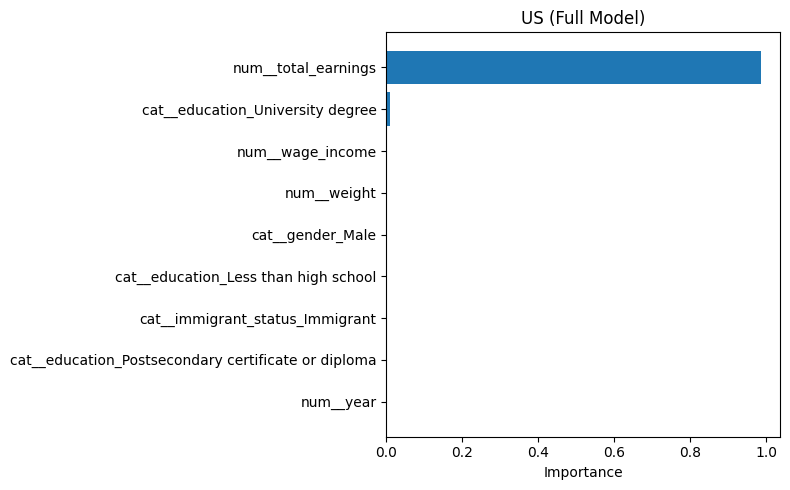

In [ ]:
top_features_us = feature_imp_df_us.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features_us["Feature"], top_features_us["Importance"])
plt.gca().invert_yaxis()
plt.title("US (Full Model)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In the full US model, total earnings explains almost all of total income. This means that the model is mostly capturing direct income relationships rather than deeper structural factors like education or immigration status.

The model is predicting income using itself, therefore, we need a structural model to understand the real drivers.

## **3.3.** Structural Model.

To understand better demographic and immigrant labour market effects, we constructed a structural model excluding income component variables (earnings, wages and survey weight).

In [ ]:
structural_features_us = [
    "year",
    "gender",
    "education",
    "immigrant_status"
]

In [ ]:
X_struct_us = train_us[structural_features_us].copy()
y_struct_reg_us = train_us["total_income"].copy()
y_struct_clf_us = train_us["income_level"].copy()

In [ ]:
X_test_struct_us = test_us[structural_features_us].copy()
y_test_struct_reg_us = test_us["total_income"].copy()
y_test_struct_clf_us = test_us["income_level"].copy()

In [ ]:
X_train_struct_reg, X_val_struct_reg, y_train_struct_reg, y_val_struct_reg = train_test_split(X_struct_us, y_struct_reg_us, test_size=0.2, random_state=42)

In [ ]:
X_train_struct_clf, X_val_struct_clf, y_train_struct_clf, y_val_struct_clf = train_test_split(X_struct_us, y_struct_clf_us, test_size=0.2, random_state=42, stratify=y_struct_clf_us)

In [ ]:
numeric_features_struct = ["year"]
categorical_features_struct = ["gender", "education", "immigrant_status"]

In [ ]:
numeric_transformer_struct = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler())
])

categorical_transformer_struct = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor_struct = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_struct, numeric_features_struct),
        ("cat", categorical_transformer_struct, categorical_features_struct),
    ],
    remainder="drop"
)

### **3.3.1.** Regression.

### **3.3.1.1.** Training and Validating the Regression Model.

In [ ]:
reg_models_struct = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=150, learning_rate= 0.1, max_depth=3)
}

reg_rows = []
reg_pipes = {}

for name, model in reg_models_struct.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_struct),
        ("model", model)
    ])
    pipe.fit(X_train_struct_reg, y_train_struct_reg)

    train_pred = pipe.predict(X_train_struct_reg)
    val_pred = pipe.predict(X_val_struct_reg)

    reg_rows.append({
        "Model": name,
        "Train R2": r2_score(y_train_struct_reg, train_pred),
        "Val R2": r2_score(y_val_struct_reg, val_pred),
        "Train MAE": mean_absolute_error(y_train_struct_reg, train_pred),
        "Val MAE": mean_absolute_error(y_val_struct_reg, val_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train_struct_reg, train_pred)),
        "Val RMSE": np.sqrt(mean_squared_error(y_val_struct_reg, val_pred)),
    })
    reg_pipes[name] = pipe

reg_results_table = pd.DataFrame(reg_rows).round(4).sort_values(by="Val R2", ascending=False)
reg_results_table


,Model,Train R2,Val R2,Train MAE,Val MAE,Train RMSE,Val RMSE
4,Gradient Boosting,0.1601,0.1570,40897.1368,41694.9119,75942.3632,77041.6395
2,Random Forest,0.1603,0.1567,40897.0185,41702.0294,75934.1555,77055.7545
1,Decision Tree,0.1603,0.1567,40898.2205,41703.7322,75934.0703,77056.5889
0,Linear Regression,0.1518,0.1494,41236.6775,42052.9649,76318.0242,77390.2189
3,KNN,0.0804,0.0780,44142.4291,45116.6252,79461.5364,80571.3681


### **3.3.1.2.** Testing the Structual Model.

In [ ]:
best_reg_model_struct = reg_results_table.iloc[0]["Model"]
best_reg_pipe_struct = reg_pipes[best_reg_model_struct]

test_pred_reg = best_reg_pipe_struct.predict(X_test_struct_us)

reg_test_struct = pd.DataFrame([{
    "Best Model": best_reg_model_struct,
    "Test R2": r2_score(y_test_struct_reg_us, test_pred_reg),
    "Test MAE": mean_absolute_error(y_test_struct_reg_us, test_pred_reg),
    "Test RMSE": np.sqrt(mean_squared_error(y_test_struct_reg_us, test_pred_reg)),
}]).round(4)

print("=== STRUCTURAL REGRESSION (Test on Rest of US) ===")
display(reg_test_struct)

=== STRUCTURAL REGRESSION (Test on Rest of US) ===


,Best Model,Test R2,Test MAE,Test RMSE
0,Gradient Boosting,0.1201,36033.9016,63359.8999


### **3.3.2.** Classification.

### **3.3.2.1.** Training and Validating the Classification model.

In [ ]:
classification_models_s = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, max_depth=15, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, n_estimators=150, learning_rate= 0.1, max_depth=3)
}

clf_rows_s = []
clf_pipes_s = {}

for name, model in classification_models_s.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor_struct),
        ("model", model)
    ])

    pipe.fit(X_train_struct_clf, y_train_struct_clf)

    train_pred = pipe.predict(X_train_struct_clf)
    val_pred = pipe.predict(X_val_struct_clf)

    clf_rows_s.append({
        "Model": name,
        "Train Acc": accuracy_score(y_train_struct_clf, train_pred),
        "Val Acc": accuracy_score(y_val_struct_clf, val_pred),
        "Train F1": f1_score(y_train_struct_clf, train_pred, average="weighted"),
        "Val F1": f1_score(y_val_struct_clf, val_pred, average="weighted"),
    })

    clf_pipes_s[name] = pipe

clf_results_s = pd.DataFrame(clf_rows_s).round(4).sort_values(by="Val F1", ascending=False)
print("\n=== STRUCTURAL CLASSIFICATION (Train vs Val) ===")
display(clf_results_s)


=== STRUCTURAL CLASSIFICATION (Train vs Val) ===


,Model,Train Acc,Val Acc,Train F1,Val F1
1,Decision Tree,0.5086,0.5057,0.5033,0.5008
4,Gradient Boosting,0.5083,0.5062,0.5026,0.5008
2,Random Forest,0.5086,0.5057,0.5033,0.5008
0,Logistic Regression,0.5032,0.5027,0.4934,0.4936
3,KNN,0.4824,0.4820,0.4616,0.4619


### **3.3.2.2.** Testing the Classification Model.

In [ ]:
best_clf_model_s = clf_results_s.iloc[0]["Model"]
best_clf_pipe_s = clf_pipes_s[best_clf_model_s]

test_pred_clf_s = best_clf_pipe_s.predict(X_test_struct_us)

print("\nBest Structural Classification Model:", best_clf_model_s)
print("Test Accuracy:", round(accuracy_score(y_test_struct_clf_us, test_pred_clf_s), 4))
print("Test F1:", round(f1_score(y_test_struct_clf_us, test_pred_clf_s, average="weighted"), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test_struct_clf_us, test_pred_clf_s))
print("\nClassification Report:\n", classification_report(y_test_struct_clf_us, test_pred_clf_s))


Best Structural Classification Model: Decision Tree
Test Accuracy: 0.4905
Test F1: 0.4824
Confusion Matrix:
 [[44182  7727 14947]
 [17257 44849 23449]
 [30954 29404 30111]]

Classification Report:
               precision    recall  f1-score   support

        High       0.48      0.66      0.55     66856
         Low       0.55      0.52      0.54     85555
      Medium       0.44      0.33      0.38     90469

    accuracy                           0.49    242880
   macro avg       0.49      0.51      0.49    242880
weighted avg       0.49      0.49      0.48    242880



###**3.4. Feature Importance For Structural Model.**

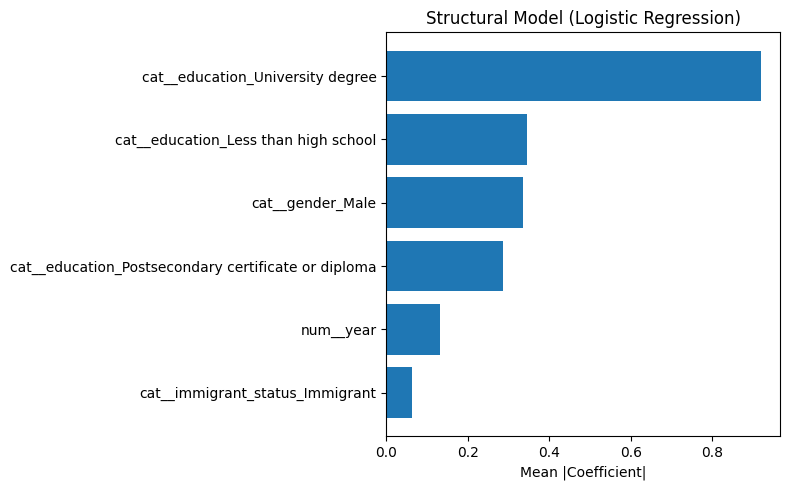

In [ ]:
logistic_pipe = clf_pipes_s["Logistic Regression"]

clf_model = logistic_pipe.named_steps["model"]
preprocessor = logistic_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefs = clf_model.coef_

# Convert to overall importance
importance = np.mean(np.abs(coefs), axis=0)

feature_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

top_features = feature_imp_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Structural Model (Logistic Regression)")
plt.xlabel("Mean |Coefficient|")
plt.tight_layout()
plt.show()

This chart answers the question:

**When earnings and wage variables are removed, what factors help the model classify individuals into Low, Medium, or High income groups?**

The results show that education is the strongest structural determinant of income classification, with a university degree having the largest influence. Other education levels also contribute meaningfully to income grouping.

Gender also plays a moderate role in determining income category.

Immigrant status has a comparatively small influence on income classification in the US structural model.

Overall, this indicates that in the United States, education is the dominant driver of income level, while immigrant status plays a weaker structural role once education and gender are accounted for.

## **4.0.** Bridging the Gap.

### **4.1. Does immigrant status push one's income towards Low, Medium or High Income level?**

Using Logistic regression because it provides directional coefficients, which allows us to see if Immigrant status increases or decreases the probability of being in a Low, Medium or High Income group.

In [ ]:
logistic_pipe_us = clf_pipes_s["Logistic Regression"]

clf_model_us = logistic_pipe_us.named_steps["model"]
preprocessor_us = logistic_pipe_us.named_steps["preprocessor"]

feature_names_us = preprocessor_us.get_feature_names_out()

coef_df_us = pd.DataFrame(
    clf_model_us.coef_,
    columns=feature_names_us,
    index=clf_model_us.classes_
)

coef_df_us[["cat__immigrant_status_Immigrant"]]

,cat__immigrant_status_Immigrant
High,-0.057429
Low,-0.036343
Medium,0.093771


In the US, Immigrants are pushed towards the Middle income group.

In the US structural logistic regression model, immigrant status does not strongly push individuals toward the low-income group. Instead, immigrants are slightly more likely to fall within the middle-income category and slightly less likely to be in the high-income group. This contrasts with the Canadian results, where immigrant status significantly increased the probability of being in the low-income group.

### **4.2. Does Education reduce the income gap between immigrants and native born individuals?**

In [ ]:
income_comparison_us = (
    train_us
    .groupby(["education", "immigrant_status"])["total_income"]
    .mean()
    .reset_index()
)

income_comparison_us

,education,immigrant_status,total_income
0,High school diploma,Born in US,36548.152039
1,High school diploma,Immigrant,34234.229743
2,Less than high school,Born in US,22781.971283
3,Less than high school,Immigrant,26488.057757
4,Postsecondary certificate or diploma,Born in US,45777.546802
5,Postsecondary certificate or diploma,Immigrant,45462.220915
6,University degree,Born in US,98635.153943
7,University degree,Immigrant,99215.244129


In [ ]:
income_pivot = income_comparison_us.pivot(
    index="education",
    columns="immigrant_status",
    values="total_income"
)

income_pivot

immigrant_status,Born in US,Immigrant
education,,
High school diploma,36548.152039,34234.229743
Less than high school,22781.971283,26488.057757
Postsecondary certificate or diploma,45777.546802,45462.220915
University degree,98635.153943,99215.244129


In [ ]:
income_pivot["Income_Gap"] = (
    income_pivot["Born in US"] -
    income_pivot["Immigrant"]
)

income_pivot

immigrant_status,Born in US,Immigrant,Income_Gap
education,,,
High school diploma,36548.152039,34234.229743,2313.922295
Less than high school,22781.971283,26488.057757,-3706.086474
Postsecondary certificate or diploma,45777.546802,45462.220915,315.325886
University degree,98635.153943,99215.244129,-580.090186


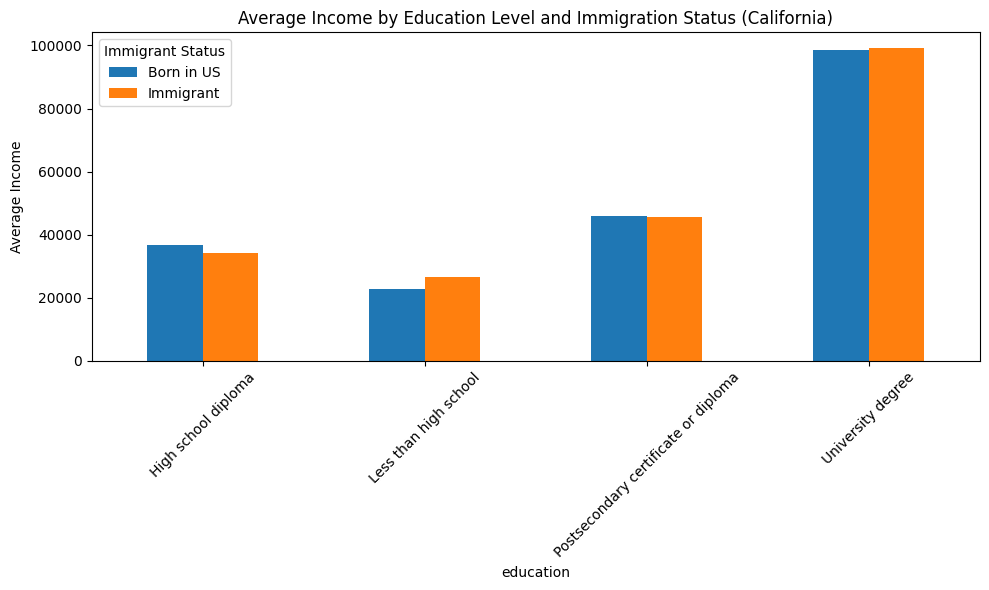

In [ ]:
income_pivot[["Born in US", "Immigrant"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Income by Education Level and Immigration Status (California)")
plt.ylabel("Average Income")
plt.xticks(rotation=45)
plt.legend(title="Immigrant Status")
plt.tight_layout()
plt.show()

### **Cross Country Structural Comparison.**

| Metric                                 | Canada     | US            |
| -------------------------------------- | ---------- | ------------- |
| Structural R² (Regression)             | 0.1303         | 0.1199            |
| Structural Accuracy (Classification)   | 0.4931         | 0.4905            |
| Immigrant Status Pushes Toward         | Low Income | Medium Income |
| Education Strongest Predictor?         | Yes        | Yes           |
| Income Gap Widens at University Level? | Yes        | No      |


# **ANN - Using Tensor Flow.**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

Structural Regression Data for ANN

In [ ]:
# Transform structural inputs for regression
X_train_reg_tf = preprocessor_struct.fit_transform(X_train_struct_reg)
X_val_reg_tf = preprocessor_struct.transform(X_val_struct_reg)
X_test_reg_tf = preprocessor_struct.transform(X_test_struct_us)

# Convert sparse matrices to dense arrays if needed
X_train_reg_tf = X_train_reg_tf.toarray() if hasattr(X_train_reg_tf, "toarray") else X_train_reg_tf
X_val_reg_tf = X_val_reg_tf.toarray() if hasattr(X_val_reg_tf, "toarray") else X_val_reg_tf
X_test_reg_tf = X_test_reg_tf.toarray() if hasattr(X_test_reg_tf, "toarray") else X_test_reg_tf

Build the ANN Regression Model.

In [ ]:
ann_reg = Sequential([
    Input(shape=(X_train_reg_tf.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

In [ ]:
ann_reg.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
early_stop_reg = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

Training the ANN Regression Model.

In [ ]:
history_reg = ann_reg.fit(
    X_train_reg_tf,
    y_train_struct_reg,
    validation_data=(X_val_reg_tf, y_val_struct_reg),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_reg],
    verbose=0
)

Making Predictions.

In [ ]:
train_pred_ann_reg = ann_reg.predict(X_train_reg_tf, verbose=0).flatten()
val_pred_ann_reg = ann_reg.predict(X_val_reg_tf, verbose=0).flatten()
test_pred_ann_reg = ann_reg.predict(X_test_reg_tf, verbose=0).flatten()

Evaluating Regression Performance.

In [ ]:
print("=== US TensorFlow Structural Regression ===")
print("Train R2:", round(r2_score(y_train_struct_reg, train_pred_ann_reg), 4))
print("Val R2:", round(r2_score(y_val_struct_reg, val_pred_ann_reg), 4))
print("Test R2:", round(r2_score(y_test_struct_reg_us, test_pred_ann_reg), 4))

print("Train MAE:", round(mean_absolute_error(y_train_struct_reg, train_pred_ann_reg), 4))
print("Val MAE:", round(mean_absolute_error(y_val_struct_reg, val_pred_ann_reg), 4))
print("Test MAE:", round(mean_absolute_error(y_test_struct_reg_us, test_pred_ann_reg), 4))

print("Train RMSE:", round(np.sqrt(mean_squared_error(y_train_struct_reg, train_pred_ann_reg)), 4))
print("Val RMSE:", round(np.sqrt(mean_squared_error(y_val_struct_reg, val_pred_ann_reg)), 4))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test_struct_reg_us, test_pred_ann_reg)), 4))

=== US TensorFlow Structural Regression ===
Train R2: 0.1579
Val R2: 0.1556
Test R2: 0.1206
Train MAE: 40780.3511
Val MAE: 41561.9081
Test MAE: 35884.2665
Train RMSE: 76041.5406
Val RMSE: 77106.1225
Test RMSE: 63343.2836


Structural Classification Data.

In [ ]:
# Transform structural inputs for classification
X_train_clf_tf = preprocessor_struct.fit_transform(X_train_struct_clf)
X_val_clf_tf = preprocessor_struct.transform(X_val_struct_clf)
X_test_clf_tf = preprocessor_struct.transform(X_test_struct_us)

X_train_clf_tf = X_train_clf_tf.toarray() if hasattr(X_train_clf_tf, "toarray") else X_train_clf_tf
X_val_clf_tf = X_val_clf_tf.toarray() if hasattr(X_val_clf_tf, "toarray") else X_val_clf_tf
X_test_clf_tf = X_test_clf_tf.toarray() if hasattr(X_test_clf_tf, "toarray") else X_test_clf_tf

Encoding the target labels.

In [ ]:
label_encoder_us = LabelEncoder()
y_train_clf_enc = label_encoder_us.fit_transform(y_train_struct_clf)
y_val_clf_enc = label_encoder_us.transform(y_val_struct_clf)
y_test_clf_enc = label_encoder_us.transform(y_test_struct_clf_us)

num_classes = len(label_encoder_us.classes_)

Building the ANN Classification Model.

In [ ]:
ann_clf = Sequential([
    Input(shape=(X_train_clf_tf.shape[1],)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

Compiling the Classification Model.

In [ ]:
ann_clf.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

Early Stopping for Classification: When Validation performance stops improving.

In [ ]:
early_stop_clf = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

Training the ANN Classifier.

In [ ]:
history_clf = ann_clf.fit(
    X_train_clf_tf,
    y_train_clf_enc,
    validation_data=(X_val_clf_tf, y_val_clf_enc),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_clf],
    verbose=0
)

Making Classification Predictions.

In [ ]:
train_pred_probs = ann_clf.predict(X_train_clf_tf, verbose=0)
val_pred_probs = ann_clf.predict(X_val_clf_tf, verbose=0)
test_pred_probs = ann_clf.predict(X_test_clf_tf, verbose=0)

train_pred_ann_clf = np.argmax(train_pred_probs, axis=1)
val_pred_ann_clf = np.argmax(val_pred_probs, axis=1)
test_pred_ann_clf = np.argmax(test_pred_probs, axis=1)

Evaluate Classification Performance.

In [ ]:
print("=== US TensorFlow Structural Classification ===")
print("Train Accuracy:", round(accuracy_score(y_train_clf_enc, train_pred_ann_clf), 4))
print("Val Accuracy:", round(accuracy_score(y_val_clf_enc, val_pred_ann_clf), 4))
print("Test Accuracy:", round(accuracy_score(y_test_clf_enc, test_pred_ann_clf), 4))

print("Train F1:", round(f1_score(y_train_clf_enc, train_pred_ann_clf, average="weighted"), 4))
print("Val F1:", round(f1_score(y_val_clf_enc, val_pred_ann_clf, average="weighted"), 4))
print("Test F1:", round(f1_score(y_test_clf_enc, test_pred_ann_clf, average="weighted"), 4))

print("\nClassification Report (Test):")
print(classification_report(y_test_clf_enc, test_pred_ann_clf, target_names=label_encoder_us.classes_))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_clf_enc, test_pred_ann_clf))

=== US TensorFlow Structural Classification ===
Train Accuracy: 0.5078
Val Accuracy: 0.5063
Test Accuracy: 0.4917
Train F1: 0.5029
Val F1: 0.5018
Test F1: 0.4845

Classification Report (Test):
              precision    recall  f1-score   support

        High       0.48      0.65      0.55     66856
         Low       0.55      0.52      0.54     85555
      Medium       0.44      0.34      0.38     90469

    accuracy                           0.49    242880
   macro avg       0.49      0.51      0.49    242880
weighted avg       0.49      0.49      0.48    242880


Confusion Matrix (Test):
[[43639  7727 15490]
 [16684 44849 24022]
 [30139 29404 30926]]


Saving the models for the application.

In [ ]:
joblib.dump(preprocessor_struct, "us_tf_struct_preprocessor.pkl")
joblib.dump(label_encoder_us, "us_tf_struct_label_encoder.pkl")

ann_reg.save("us_tf_struct_regressor.keras")
ann_clf.save("us_tf_struct_classifier.keras")

print("US TensorFlow structural models saved successfully.")

US TensorFlow structural models saved successfully.


In [ ]:
import joblib

joblib.dump(best_reg_pipe_struct, "us_structural_regressor.pkl")
joblib.dump(best_clf_pipe_s, "us_structural_classifier.pkl")
joblib.dump({"q1": q1, "q2": q2}, "us_income_cutoffs.pkl")

['us_income_cutoffs.pkl']

### **REGRESSION.**

| Metric                                 | Gradient Boosting     | ANN            |
| -------------------------------------- | ---------- | ------------- |
| Test R²            | 0.1201         | 0.1206            |
| Test RMSE   | 63359         | 63343            |

The ANN performed slightly better than Gradient Boosting, but the difference is very small.

This means both models are almost equally good at predicting income, and the added complexity of the neural network does not provide a meaningful advantage.

### **CLASSIFICATION.**

| Metric                                 | Decision Tree     | ANN            |
| -------------------------------------- | ---------- | ------------- |
| Accuracy             | 0.4905         | 0.4917            |
| F1-Score   | 0.4824         | 0.4845            |

The ANN slightly outperforms the Decision Tree, but the improvement is marginal.